**PREPROCESSING + ML(RANDOMFOREST)**




In [ ]:
import os
import warnings
import numpy as np
import pandas as pd
import joblib

from sklearn.model_selection import train_test_split, RandomizedSearchCV
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings('ignore')
df = pd.read_excel('HotelData.xlsx')

df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']
df['total_guests'] = df['no_of_adults'] + df['no_of_children']
df['price_per_guest'] = df['avg_price_per_room'] / (df['total_guests'] + 1)
df['weekend_ratio'] = df['no_of_weekend_nights'] / (df['total_nights'] + 1)

date_str = df['arrival_year'].astype(str) + '-' + df['arrival_month'].astype(str) + '-' + df['arrival_date'].astype(str)
df['arrival_full_date'] = pd.to_datetime(date_str, errors='coerce')
df.dropna(subset=['arrival_full_date'], inplace=True)

df['arrival_day_of_week'] = df['arrival_full_date'].dt.dayofweek
df['arrival_month_num'] = df['arrival_full_date'].dt.month

df.drop(columns=['arrival_year', 'arrival_month', 'arrival_date', 'arrival_full_date'], errors='ignore', inplace=True)

df['booking_status'] = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

X = df.drop('booking_status', axis=1)
y = df['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

print("3. Preprocessing...")


skewed_cols = ['lead_time', 'avg_price_per_room', 'price_per_guest']
for col in skewed_cols:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])


cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', fill_value=0, axis=1)

print("4. SMOTE + Scaling...")

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = MinMaxScaler()
X_train_res_scaled = pd.DataFrame(scaler.fit_transform(X_train_res), columns=X_train_res.columns)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=X_test.columns)

print("5. Training Optimized Model...")

param_dist = {
    'n_estimators': [150, 200, 250],
    'max_depth': [8, 10, 12, 15],
    'min_samples_split': [5, 10],
    'min_samples_leaf': [2, 4],
    'max_features': ['sqrt', 0.8]
}

model = RandomForestClassifier(random_state=42, n_jobs=-1)

search = RandomizedSearchCV(model, param_dist, n_iter=12, cv=5,
                          scoring='f1', random_state=42, n_jobs=-1)
search.fit(X_train_res_scaled, y_train_res)

best_model = search.best_estimator_
print("Best Params:", search.best_params_)

print("\n=== Final Evaluation ===")
y_pred = best_model.predict(X_test_scaled)

print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Recall   : {recall_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


output_dir = './final_model'
os.makedirs(output_dir, exist_ok=True)
joblib.dump(best_model, f'{output_dir}/best_rf_model.pkl')
joblib.dump(scaler, f'{output_dir}/scaler.pkl')
print(f"\nModel saved in {output_dir}")

3. Preprocessing...
4. SMOTE + Scaling...
5. Training Optimized Model...
Best Params: {'n_estimators': 200, 'min_samples_split': 10, 'min_samples_leaf': 4, 'max_features': 0.8, 'max_depth': 15}

=== Final Evaluation ===
Test Accuracy : 0.8258
Test Recall   : 0.7605

Classification Report:
              precision    recall  f1-score   support

           0       0.90      0.85      0.88      3703
           1       0.67      0.76      0.71      1453

    accuracy                           0.83      5156
   macro avg       0.78      0.81      0.79      5156
weighted avg       0.83      0.83      0.83      5156


Model saved in ./final_model


**DL(NEURAL NETWORK)**

After SMOTE: (29622, 19)


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                 │ (None, 512)            │        10,240 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_3 (Dropout)             │ (None, 512)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_6 (Dense)                 │ (None, 256)            │       131,328 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_4 (Dropout)             │ (None, 256)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_7 (Dense)                 │ (None, 128)            │        32,896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_5 (Dropout)             │ (None, 128)            │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 64)             │         8,256 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_6 (Dropout)             │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 1)              │            65 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 182,785 (714.00 KB)

 Trainable params: 182,785 (714.00 KB)

 Non-trainable params: 0 (0.00 B)

Epoch 1/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 5s 9ms/step - accuracy: 0.6954 - auc: 0.7566 - loss: 0.5550 - val_accuracy: 0.6844 - val_auc: 0.0000e+00 - val_loss: 0.6674 - learning_rate: 0.0010
Epoch 2/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7314 - auc: 0.7982 - loss: 0.5182 - val_accuracy: 0.6603 - val_auc: 0.0000e+00 - val_loss: 0.6324 - learning_rate: 0.0010
Epoch 3/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 8ms/step - accuracy: 0.7443 - auc: 0.8122 - loss: 0.5042 - val_accuracy: 0.4032 - val_auc: 0.0000e+00 - val_loss: 0.8080 - learning_rate: 0.0010
Epoch 4/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 5s 8ms/step - accuracy: 0.7492 - auc: 0.8194 - loss: 0.4968 - val_accuracy: 0.7116 - val_auc: 0.0000e+00 - val_loss: 0.6012 - learning_rate: 0.0010
Epoch 5/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 4s 11ms/step - accuracy: 0.7640 - auc: 0.8306 - loss: 0.4839 - val_accuracy: 0.7283 - val_auc: 0.0000e+00 - val_loss: 0.5779 - learning_rate: 0.0010
Epoch 6/80
371/371 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step - accu

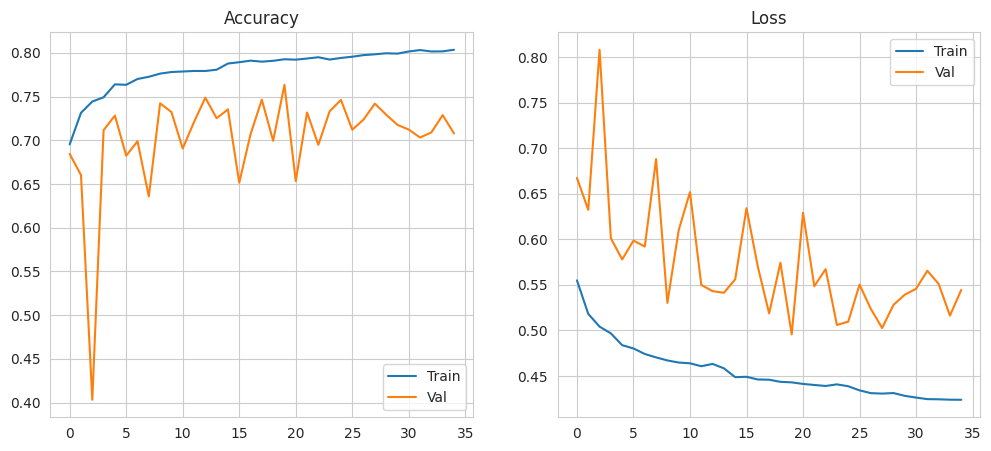

In [ ]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score
from imblearn.over_sampling import SMOTE
import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau
import joblib
import matplotlib.pyplot as plt

df = pd.read_excel('HotelData.xlsx')

df['total_nights'] = df['no_of_weekend_nights'] + df['no_of_week_nights']
df['total_guests'] = df['no_of_adults'] + df['no_of_children']
df['price_per_guest'] = df['avg_price_per_room'] / (df['total_guests'] + 1)
df['weekend_ratio'] = df['no_of_weekend_nights'] / (df['total_nights'] + 1)

date_str = df['arrival_year'].astype(str) + '-' + df['arrival_month'].astype(str) + '-' + df['arrival_date'].astype(str)
df['arrival_full_date'] = pd.to_datetime(date_str, errors='coerce')
df.dropna(subset=['arrival_full_date'], inplace=True)

df['arrival_day_of_week'] = df['arrival_full_date'].dt.dayofweek

df.drop(columns=['arrival_year', 'arrival_month', 'arrival_date', 'arrival_full_date'], errors='ignore', inplace=True)

df['booking_status'] = df['booking_status'].map({'Canceled': 1, 'Not_Canceled': 0})

X = df.drop('booking_status', axis=1)
y = df['booking_status']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)

cat_cols = X_train.select_dtypes(include=['object']).columns.tolist()
X_train = pd.get_dummies(X_train, columns=cat_cols, drop_first=True)
X_test = pd.get_dummies(X_test, columns=cat_cols, drop_first=True)
X_train, X_test = X_train.align(X_test, join='left', fill_value=0, axis=1)

skewed = ['lead_time', 'avg_price_per_room', 'price_per_guest']
for col in skewed:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = MinMaxScaler()
X_train_scaled = scaler.fit_transform(X_train_res)
X_test_scaled = scaler.transform(X_test)

print(f"After SMOTE: {X_train_scaled.shape}")

model = Sequential([
    Dense(512, activation='relu', input_shape=(X_train_scaled.shape[1],)),
    Dropout(0.4),
    Dense(256, activation='relu'),
    Dropout(0.35),
    Dense(128, activation='relu'),
    Dropout(0.3),
    Dense(64, activation='relu'),
    Dropout(0.2),
    Dense(1, activation='sigmoid')
])

model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='binary_crossentropy',
    metrics=['accuracy', tf.keras.metrics.AUC(name='auc')]
)

model.summary()


callbacks = [
    EarlyStopping(monitor='val_loss', patience=15, restore_best_weights=True),
    ReduceLROnPlateau(monitor='val_loss', factor=0.5, patience=5, min_lr=1e-6)
]

history = model.fit(
    X_train_scaled, y_train_res,
    epochs=80,
    batch_size=64,
    validation_split=0.2,
    callbacks=callbacks,
    verbose=1
)

y_pred_prob = model.predict(X_test_scaled)
y_pred = (y_pred_prob > 0.5).astype(int).flatten()

print("\n=== Improved Neural Network Results ===")
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Recall   : {recall_score(y_test, y_pred):.4f}")
print("\nClassification Report:")
print(classification_report(y_test, y_pred))


plt.figure(figsize=(12,5))
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train')
plt.plot(history.history['val_accuracy'], label='Val')
plt.title('Accuracy')
plt.legend()

plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train')
plt.plot(history.history['val_loss'], label='Val')
plt.title('Loss')
plt.legend()
plt.show()

**GUI(USING GRADIO)**

In [14]:
# =========================================================================
# Hotel Booking Cancellation — Training + Explainable Gradio GUI
# NOTE: this script fully replaces the PREPROCESSING+ML cell and the
# GUI(GRADIO) cell in the Project_NTI notebook. Run it in an environment
# that has HotelData.xlsx in the same folder.
# =========================================================================

# ---- 0) install (if not already installed) ----
# !pip install gradio shap imbalanced-learn -q

import os
import warnings
import numpy as np
import pandas as pd
import joblib
import shap
import gradio as gr

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import classification_report, accuracy_score, recall_score
from imblearn.over_sampling import SMOTE
from sklearn.ensemble import RandomForestClassifier

warnings.filterwarnings("ignore")

# =========================================================================
# 1) PREPROCESSING + TRAINING
# =========================================================================
df = pd.read_excel("HotelData.xlsx")

df["total_nights"] = df["no_of_weekend_nights"] + df["no_of_week_nights"]
df["total_guests"] = df["no_of_adults"] + df["no_of_children"]
df["price_per_guest"] = df["avg_price_per_room"] / (df["total_guests"] + 1)
df["weekend_ratio"] = df["no_of_weekend_nights"] / (df["total_nights"] + 1)

date_str = (
    df["arrival_year"].astype(str)
    + "-"
    + df["arrival_month"].astype(str)
    + "-"
    + df["arrival_date"].astype(str)
)
df["arrival_full_date"] = pd.to_datetime(date_str, errors="coerce")
df.dropna(subset=["arrival_full_date"], inplace=True)
df["arrival_day_of_week"] = df["arrival_full_date"].dt.dayofweek
df["arrival_month_num"] = df["arrival_full_date"].dt.month
df.drop(
    columns=["arrival_year", "arrival_month", "arrival_date", "arrival_full_date"],
    errors="ignore",
    inplace=True,
)

df["booking_status"] = df["booking_status"].map({"Canceled": 1, "Not_Canceled": 0})

X = df.drop("booking_status", axis=1)
y = df["booking_status"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

SKEWED_COLS = ["lead_time", "avg_price_per_room", "price_per_guest"]
for col in SKEWED_COLS:
    X_train[col] = np.log1p(X_train[col])
    X_test[col] = np.log1p(X_test[col])

CAT_COLS = X_train.select_dtypes(include=["object"]).columns.tolist()
X_train = pd.get_dummies(X_train, columns=CAT_COLS, drop_first=True)
X_test = pd.get_dummies(X_test, columns=CAT_COLS, drop_first=True)
X_train, X_test = X_train.align(X_test, join="left", fill_value=0, axis=1)

TRAINING_COLUMNS = X_train.columns.tolist()

smote = SMOTE(random_state=42)
X_train_res, y_train_res = smote.fit_resample(X_train, y_train)

scaler = MinMaxScaler()
X_train_res_scaled = pd.DataFrame(
    scaler.fit_transform(X_train_res), columns=TRAINING_COLUMNS
)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=TRAINING_COLUMNS)

model = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    min_samples_split=5,
    min_samples_leaf=2,
    max_features="sqrt",
    random_state=42,
    n_jobs=-1,
)
model.fit(X_train_res_scaled, y_train_res)

y_pred = model.predict(X_test_scaled)
print(f"Test Accuracy : {accuracy_score(y_test, y_pred):.4f}")
print(f"Test Recall   : {recall_score(y_test, y_pred):.4f}")
print(classification_report(y_test, y_pred))

output_dir = "./final_model"
os.makedirs(output_dir, exist_ok=True)
joblib.dump(model, f"{output_dir}/best_rf_model.pkl")
joblib.dump(scaler, f"{output_dir}/scaler.pkl")
joblib.dump(TRAINING_COLUMNS, f"{output_dir}/training_columns.pkl")
joblib.dump(CAT_COLS, f"{output_dir}/cat_cols.pkl")
print("Model + scaler + columns saved.")

# =========================================================================
# 2) SHAP EXPLAINER (local, per-prediction explanation)
# =========================================================================
explainer = shap.TreeExplainer(model)

# IMPORTANT: HotelData.xlsx only has ONE categorical column (type_of_meal_plan).
# There are no room_type_reserved / market_segment_type columns in this file,
# so those two features never entered training. If you want to use them,
# they need to exist in the Excel file at training time.

# Human-readable name for each original feature (used in the explanation list)
FEATURE_DISPLAY_NAME = {
    "lead_time": "Lead time",
    "avg_price_per_room": "Average price per room",
    "price_per_guest": "Price per guest",
    "no_of_special_requests": "Special requests",
    "repeated_guest": "Repeated guest",
    "required_car_parking_space": "Parking space request",
    "no_of_previous_cancellations": "Previous cancellations",
    "no_of_previous_bookings_not_canceled": "Previous successful bookings",
    "arrival_month_num": "Arrival month",
    "arrival_day_of_week": "Arrival day of week",
    "total_nights": "Total nights",
    "total_guests": "Total guests",
    "weekend_ratio": "Weekend-nights ratio",
    "no_of_week_nights": "Week nights",
    "no_of_weekend_nights": "Weekend nights",
    "no_of_adults": "Adults",
    "no_of_children": "Children",
    "type_of_meal_plan": "Meal plan",
}

MONTH_NAMES = [
    "", "January", "February", "March", "April", "May", "June",
    "July", "August", "September", "October", "November", "December",
]
WEEKDAY_NAMES = ["Monday", "Tuesday", "Wednesday", "Thursday", "Friday", "Saturday", "Sunday"]


def format_value(feature: str, value) -> str:
    """Turn a raw feature value into a short, readable string for the explanation."""
    try:
        if feature == "arrival_month_num":
            return MONTH_NAMES[int(value)]
        if feature == "arrival_day_of_week":
            return WEEKDAY_NAMES[int(value) % 7]
        if feature == "repeated_guest":
            return "Yes" if value == 1 else "No"
        if feature == "required_car_parking_space":
            return "Requested" if value == 1 else "Not requested"
        if feature in ("avg_price_per_room", "price_per_guest"):
            return f"${float(value):.0f}"
        if feature == "weekend_ratio":
            return f"{float(value):.2f}"
        if feature == "type_of_meal_plan":
            return str(value)
        if float(value).is_integer():
            return f"{int(value)}"
        return f"{float(value):.1f}"
    except (ValueError, TypeError, IndexError):
        return str(value)


def display_name(base_feature: str) -> str:
    return FEATURE_DISPLAY_NAME.get(base_feature, base_feature.replace("_", " "))


def base_feature_name(col: str) -> str:
    """Map a (possibly dummy-encoded) training column back to its original feature."""
    for cat in CAT_COLS:
        if col == cat or col.startswith(cat + "_"):
            return cat
    return col


def impact_level(abs_shap_value: float) -> str:
    """Bucket the magnitude of a SHAP contribution into a plain-English label."""
    if abs_shap_value >= 0.10:
        return "Strong"
    if abs_shap_value >= 0.04:
        return "Moderate"
    return "Slight"


def explain_prediction(row_scaled_df: pd.DataFrame, raw_values: dict, top_n: int = 4):
    """Return the top contributing ORIGINAL features (dummy columns aggregated
    back into their source feature) for THIS specific prediction, as a list of
    dicts: {name, value_str, direction ('increase'/'decrease'), level}."""
    shap_vals = explainer.shap_values(row_scaled_df)[0, :, 1]  # class = Canceled
    contrib = pd.Series(shap_vals, index=TRAINING_COLUMNS)

    # aggregate dummy columns back into their original categorical feature
    grouped = {}
    for col, val in contrib.items():
        base = base_feature_name(col)
        grouped[base] = grouped.get(base, 0.0) + val

    grouped = pd.Series(grouped).sort_values(key=lambda s: s.abs(), ascending=False)
    top = grouped.head(top_n)

    reasons = []
    for feat, val in top.items():
        reasons.append(
            {
                "name": display_name(feat),
                "value_str": format_value(feat, raw_values.get(feat, "")),
                "direction": "increase" if val > 0 else "decrease",
                "level": impact_level(abs(val)),
            }
        )
    return reasons


# =========================================================================
# 3) GRADIO GUI
# =========================================================================
best_model = joblib.load("./final_model/best_rf_model.pkl")
scaler = joblib.load("./final_model/scaler.pkl")
TRAINING_COLUMNS = joblib.load("./final_model/training_columns.pkl")
CAT_COLS = joblib.load("./final_model/cat_cols.pkl")

MEAL_OPTIONS = ["Meal Plan 1", "Meal Plan 2", "Meal Plan 3", "Not Selected"]


import datetime

BOOKINGS_FILE = "confirmed_bookings.csv"
BOOKINGS_LOG = []  # in-memory log of confirmed bookings for this session


def predict_cancellation(
    no_of_adults,
    no_of_children,
    no_of_weekend_nights,
    no_of_week_nights,
    type_of_meal_plan,
    lead_time,
    arrival_year,
    arrival_month,
    arrival_date,
    repeated_guest,
    required_car_parking_space,
    no_of_previous_cancellations,
    no_of_previous_bookings_not_canceled,
    no_of_special_requests,
    avg_price_per_room,
    threshold=50,
):
    row = {
        "no_of_adults": no_of_adults,
        "no_of_children": no_of_children,
        "no_of_weekend_nights": no_of_weekend_nights,
        "no_of_week_nights": no_of_week_nights,
        "type_of_meal_plan": type_of_meal_plan,
        "lead_time": lead_time,
        "repeated_guest": repeated_guest,
        "required_car_parking_space": required_car_parking_space,
        "no_of_previous_cancellations": no_of_previous_cancellations,
        "no_of_previous_bookings_not_canceled": no_of_previous_bookings_not_canceled,
        "no_of_special_requests": no_of_special_requests,
        "avg_price_per_room": avg_price_per_room,
    }

    df_row = pd.DataFrame([row])
    df_row["total_nights"] = df_row["no_of_weekend_nights"] + df_row["no_of_week_nights"]
    df_row["total_guests"] = df_row["no_of_adults"] + df_row["no_of_children"]
    df_row["price_per_guest"] = df_row["avg_price_per_room"] / (df_row["total_guests"] + 1)
    df_row["weekend_ratio"] = df_row["no_of_weekend_nights"] / (df_row["total_nights"] + 1)

    date_str = f"{int(arrival_year)}-{int(arrival_month)}-{int(arrival_date)}"
    arrival_full_date = pd.to_datetime(date_str, errors="coerce")
    if pd.isna(arrival_full_date):
        error_html = (
            "<div style='padding:14px 18px; border-radius:10px; background:#fffbeb; "
            "border:1px solid #f59e0b;'>"
            "<span style='color:#92400e;'>⚠️ Invalid arrival date. Please check the date.</span></div>"
        )
        return error_html, None, gr.update(interactive=False)

    df_row["arrival_day_of_week"] = arrival_full_date.dayofweek
    df_row["arrival_month_num"] = arrival_full_date.month

    # keep the raw (pre-log, pre-dummy) values around for the explanation text
    raw_values = df_row.iloc[0].to_dict()

    for col in SKEWED_COLS:
        if col in df_row.columns:
            df_row[col] = np.log1p(df_row[col])

    df_row = pd.get_dummies(df_row, columns=CAT_COLS)
    df_row = df_row.reindex(columns=TRAINING_COLUMNS, fill_value=0)

    df_scaled = pd.DataFrame(scaler.transform(df_row), columns=TRAINING_COLUMNS)

    proba = best_model.predict_proba(df_scaled)[0][1] * 100
    pred = 1 if proba >= threshold else 0

    if pred == 1:
        color = "#ef4444"
        status = "HIGH RISK - Likely to Cancel"
        icon = "❌"
    else:
        color = "#10b981"
        status = "LOW RISK - Likely Not to Cancel"
        icon = "✅"

    result_html = f"""
    <div style="text-align:center; padding:30px; border-radius:16px; background:#f8fafc; border:3px solid {color};">
        <h1 style="font-size: 3.2rem; margin:10px 0;">{icon}</h1>
        <h2 style="color:{color}; margin:10px 0;">{status}</h2>
        <h3 style="color:#1e293b; margin:20px 0 10px 0;">Cancellation Probability: <strong>{proba:.1f}%</strong></h3>
        <div style="background:#e2e8f0; height:18px; border-radius:999px; margin:15px auto; width:80%;">
            <div style="width:{proba}%; height:100%; background:{color}; border-radius:999px; transition:0.4s;"></div>
        </div>
        <p style="color:#475569; font-size:0.85rem; margin-top:10px;">This is a risk preview only — no booking has been created yet.</p>
    </div>
    """

    # ---- Explanation section: plain list, no bars, English only ----
    top_reasons = explain_prediction(df_scaled, raw_values, top_n=5)

    reason_items = ""
    for r in top_reasons:
        if r["direction"] == "increase":
            arrow, arrow_color, verb = "▲", "#ef4444", "increase"
        else:
            arrow, arrow_color, verb = "▼", "#10b981", "decrease"

        reason_items += f"""
        <li style="margin:10px 0; padding:10px 14px; background:#f8fafc; border-left:4px solid {arrow_color}; border-radius:6px; color:#1e293b;">
            <span style="color:{arrow_color}; font-weight:700; margin-right:6px;">{arrow}</span>
            <strong style="color:#1e293b;">{r['name']}</strong>: <span style="color:#1e293b;">{r['value_str']}</span>
            &nbsp;—&nbsp;<span style="color:{arrow_color};">{r['level']} {verb} in cancellation risk</span>
        </li>
        """

    explanation_html = f"""
    <div style="text-align:left; direction:ltr; padding:20px 25px; border-radius:16px; background:#ffffff; border:1px solid #e2e8f0; margin-top:15px;">
        <h3 style="color:#1e293b; margin-bottom:10px;">🔍 Why this prediction (based on what you entered)</h3>
        <ul style="list-style:none; padding-left:0;">
            {reason_items}
        </ul>
        <p style="font-size:0.8rem; color:#475569; margin-top:10px;">
        ▲ = this factor pushes the prediction toward cancellation. ▼ = this factor pushes it toward not canceling.
        Ranked by each factor's actual impact on THIS specific prediction (SHAP values), not on the dataset overall.
        </p>
    </div>
    """

    # state passed to the Confirm step — nothing is booked until the guest confirms
    pending_booking = {
        "raw_values": raw_values,
        "type_of_meal_plan": type_of_meal_plan,
        "arrival_date_str": arrival_full_date.strftime("%Y-%m-%d"),
        "cancellation_probability": round(proba, 1),
        "risk_level": status,
    }

    return result_html + explanation_html, pending_booking, gr.update(interactive=True)


def confirm_booking(pending_booking):
    """Only actually 'creates' the booking once the guest explicitly confirms it.
    Nothing is written to the bookings log by predict_cancellation alone."""
    if not pending_booking:
        warning_html = (
            "<div style='padding:14px 18px; border-radius:10px; background:#fffbeb; "
            "border:1px solid #f59e0b;'>"
            "<span style='color:#92400e;'>⚠️ Please run a prediction first, "
            "then confirm the booking.</span></div>"
        )
        return warning_html, render_bookings_table(), None, gr.update(interactive=False)

    booking_id = f"BKG-{len(BOOKINGS_LOG) + 1:04d}"
    record = {
        "booking_id": booking_id,
        "confirmed_at": datetime.datetime.now().strftime("%Y-%m-%d %H:%M:%S"),
        "arrival_date": pending_booking["arrival_date_str"],
        "meal_plan": pending_booking["type_of_meal_plan"],
        "cancellation_probability_%": pending_booking["cancellation_probability"],
        "risk_level": pending_booking["risk_level"],
    }
    BOOKINGS_LOG.append(record)

    # persist to CSV so the log survives across predictions in this session
    pd.DataFrame(BOOKINGS_LOG).to_csv(BOOKINGS_FILE, index=False)

    success_html = f"""
    <div style="padding:16px 20px; border-radius:12px; background:#ecfdf5; border:1px solid #10b981;">
        <strong style="color:#065f46;">✅ Booking confirmed — {booking_id}</strong><br>
        <span style="color:#065f46; font-size:0.9rem;">
        The booking is now recorded. Before this step, nothing was saved — the guest's
        data only existed as a risk preview.
        </span>
    </div>
    """

    # reset pending state and disable Confirm until the next prediction
    return success_html, render_bookings_table(), None, gr.update(interactive=False)


def render_bookings_table():
    if not BOOKINGS_LOG:
        return pd.DataFrame(
            columns=["booking_id", "confirmed_at", "arrival_date", "meal_plan",
                     "cancellation_probability_%", "risk_level"]
        )
    return pd.DataFrame(BOOKINGS_LOG)


with gr.Blocks(
    title="Hotel Cancellation Predictor",
    theme=gr.themes.Soft(primary_hue="blue", secondary_hue="slate"),
) as demo:
    gr.Markdown("# 🏨 Hotel Booking Cancellation Predictor")
    gr.Markdown("### AI-Powered Risk Assessment System, with an explanation of the prediction")

    with gr.Row():
        with gr.Column():
            gr.Markdown("### Guest & Stay Information")
            no_of_adults = gr.Number(label="Number of Adults", value=2)
            no_of_children = gr.Number(label="Number of Children", value=0)
            no_of_weekend_nights = gr.Number(label="Weekend Nights", value=1)
            no_of_week_nights = gr.Number(label="Week Nights", value=2)
            lead_time = gr.Number(label="Lead Time (days before arrival)", value=45)
            avg_price_per_room = gr.Number(label="Average Price per Room ($)", value=110.0)

        with gr.Column():
            gr.Markdown("### Booking Details")
            type_of_meal_plan = gr.Dropdown(MEAL_OPTIONS, label="Meal Plan", value="Meal Plan 1")
            repeated_guest = gr.Radio([0, 1], label="Repeated Guest?", value=0)
            required_car_parking_space = gr.Radio([0, 1], label="Requires Parking Space?", value=0)
            no_of_previous_cancellations = gr.Number(label="Previous Cancellations", value=0)
            no_of_previous_bookings_not_canceled = gr.Number(label="Previous Successful Bookings", value=0)
            no_of_special_requests = gr.Number(label="Number of Special Requests", value=0)

            with gr.Row():
                arrival_year = gr.Number(label="Arrival Year", value=2018)
                arrival_month = gr.Number(label="Arrival Month", value=7)
                arrival_date = gr.Number(label="Arrival Day", value=15)

    threshold = gr.Slider(30, 80, value=50, label="Decision Threshold (%)", info="Higher = more conservative")

    predict_btn = gr.Button("🔍 Predict Cancellation Risk", variant="primary", size="large")

    output = gr.HTML()

    pending_state = gr.State(value=None)

    gr.Markdown("---")
    gr.Markdown(
        "### Confirm the booking\n"
        "Nothing is booked yet — the risk check above is only a preview. "
        "The booking is created only once you press **Confirm Booking** below."
    )
    confirm_btn = gr.Button("✅ Confirm Booking", variant="secondary", interactive=False)
    confirm_output = gr.HTML()

    gr.Markdown("### Confirmed bookings (this session)")
    bookings_table = gr.Dataframe(
        value=render_bookings_table(),
        interactive=False,
        wrap=True,
    )

    predict_btn.click(
        predict_cancellation,
        inputs=[
            no_of_adults,
            no_of_children,
            no_of_weekend_nights,
            no_of_week_nights,
            type_of_meal_plan,
            lead_time,
            arrival_year,
            arrival_month,
            arrival_date,
            repeated_guest,
            required_car_parking_space,
            no_of_previous_cancellations,
            no_of_previous_bookings_not_canceled,
            no_of_special_requests,
            avg_price_per_room,
            threshold,
        ],
        outputs=[output, pending_state, confirm_btn],
    ).then(lambda: "", None, confirm_output)

    confirm_btn.click(
        confirm_booking,
        inputs=[pending_state],
        outputs=[confirm_output, bookings_table, pending_state, confirm_btn],
    )

demo.launch(share=True)

Test Accuracy : 0.8189
Test Recall   : 0.7316
              precision    recall  f1-score   support

           0       0.89      0.85      0.87      3703
           1       0.66      0.73      0.69      1453

    accuracy                           0.82      5156
   macro avg       0.78      0.79      0.78      5156
weighted avg       0.83      0.82      0.82      5156

Model + scaler + columns saved.
Colab notebook detected. To show errors in colab notebook, set debug=True in launch()
* Running on public URL: https://93b48f72c8b91d0790.gradio.live

This share link is temporary and will last for up to 1 week (best effort). For free permanent hosting and GPU upgrades, run `gradio deploy` from the terminal in the working directory to deploy to Hugging Face Spaces (https://huggingface.co/spaces)
